# FB15k-237 — Full Pipeline: Baselines + Custom Negative Sampling

Self-contained Colab notebook that reproduces every result in our
KG Deliverable 3 (D3) and DL Milestone 2 (M2) submissions.

| Section | Content |
|---------|---------|
| A | Setup — clone, install, GPU check |
| B | Dataset analysis — FB15k-237 statistics and distributions |
| C | Model background — TransE, RotatE, NSSALoss, Bernoulli corruption |
| D | Configuration — unified hyper-parameters |
| E | Baselines — TransE + RotatE training commands and results |
| F | Custom pipeline — two-stage negative sampling walkthrough |
| G | Smoke test — 1-epoch end-to-end validation (~2 min) |
| H | Full custom training — 5 strategies × 50 epochs |
| I | Training results — learning curves and global metrics |
| J | Slice evaluation — MRR by relation frequency and entity degree |
| K | Qualitative analysis — top-K predictions on test triples |
| L | Headline visualisations — summary figures for the report |
| M | Discussion and conclusions |
| N | Notes for graders |

### Unified configuration (all 7 runs)
| Parameter | Value |
|-----------|-------|
| Model | RotatE (dim = 128) for custom; TransE + RotatE for baselines |
| Loss | NSSALoss (margin = 9.0, adv. temp. = 1.0) |
| Negative sampler | Bernoulli, filtered, k = 8 negatives per positive |
| Optimiser | Adam, lr = 1e-3, batch = 1024 |
| Training | 50 epochs max, early stopping on val MRR (patience = 10) |
| Seed | 42 |

Only the **negative-selection strategy** varies across the five custom runs.

### How to use
1. Set Colab runtime to **GPU (T4)** — Runtime ▸ Change runtime type.
2. Run **Section A** once (clone + install).
3. **Section G** smoke-trains the pipeline in ~2 minutes to check everything works.
4. **Sections E and H** hold the full 50-epoch commands (commented out by default).
5. **Sections I–M** load any available checkpoints for analysis — safe to run even before training.


## A. Setup

### A.1 Clone repository

If the repo is private and the clone fails, the cell prints manual upload instructions.
Create `/content/dl_kg_project/code/` in the Colab Files panel and drop every `.py` file
from `code/` there, plus `requirements.txt` at the repo root.


In [37]:
import os, subprocess, sys
from pathlib import Path

REPO_URL  = "https://github.com/thaalia/dl_kg_project.git"
REPO_PATH = "/content/dl_kg_project"

if os.path.isdir("/content"):                          # ── Colab ──
    if not os.path.isdir(os.path.join(REPO_PATH, "code")):
        result = subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_PATH],
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            os.makedirs(os.path.join(REPO_PATH, "code"), exist_ok=True)
            print("git clone failed (private repo or no network access).")
            print("Manual upload required:")
            print(f"  1. In the Colab Files panel navigate to {REPO_PATH}/code/")
            print("  2. Upload every .py file from the local code/ folder.")
            print("  3. Upload requirements.txt at the repo root.")
            print("\nClone stderr:", result.stderr.strip())
    os.chdir(REPO_PATH)
else:                                                  # ── local ──
    root = Path.cwd()
    while not (root / "artifacts").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

REPO_ROOT = Path(os.getcwd())
ARTIFACTS = REPO_ROOT / "artifacts"
CODE      = REPO_ROOT / "code"
sys.path.insert(0, str(CODE))

print("Working directory:", REPO_ROOT)
if CODE.exists():
    print("Code files:", sorted(p.name for p in CODE.glob("*.py")))
else:
    print("code/ not found — upload files before continuing.")


Working directory: /Users/rafaelgufler/Documents/development/dl_kg_project
Code files: ['evaluate_slices.py', 'negative_sampling.py', 'qualitative_examples.py', 'score_candidates.py', 'select_candidates.py', 'test_candidates.py', 'test_score_candidates.py', 'test_select_candidates.py', 'train_baseline_kge.py', 'train_rotate_custom.py']


### A.2 Install dependencies

In [38]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### A.3 Verify GPU

In [39]:
import torch
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no GPU — full training will be impractically slow on CPU.")


PyTorch        : 2.11.0
CUDA available : False


## B. Dataset Analysis

**FB15k-237** (Toutanova & Chen, 2015) is derived from Freebase by removing the
inverse-relation leakage present in the original FB15k dataset. It is the standard
benchmark for link prediction in the KGE literature.

| Split | Triples |
|-------|---------|
| Train | 272,115 |
| Valid | 17,535 |
| Test  | 20,438 |
| **Total** | **310,088** |

**Entities**: 14,541 &nbsp;&nbsp; **Relations**: 237

Two structural properties directly motivate our experimental design:
* **Heavy-tailed relation distribution** — a handful of relations account for the
  majority of triples; hundreds appear only dozens of times. Standard random negative
  sampling ignores this imbalance.
* **Wide entity-degree range** — degrees span three orders of magnitude (1 to > 6,000).
  Low-degree entities are harder to rank regardless of strategy, motivating stratified
  (sliced) evaluation.


In [40]:
from pykeen.datasets import FB15k237
import numpy as np
from collections import Counter

print("Loading FB15k-237 ...")
dataset = FB15k237()

train_t = dataset.training.mapped_triples.numpy()
val_t   = dataset.validation.mapped_triples.numpy()
test_t  = dataset.testing.mapped_triples.numpy()

num_ent = int(dataset.training.num_entities)
num_rel = int(dataset.training.num_relations)

print(f"\nEntities  : {num_ent:,}")
print(f"Relations : {num_rel}")
print(f"Train     : {len(train_t):,}")
print(f"Valid     : {len(val_t):,}")
print(f"Test      : {len(test_t):,}")
print(f"Total     : {len(train_t)+len(val_t)+len(test_t):,}")

rel_counts = Counter(train_t[:, 1].tolist())
out_deg    = Counter(train_t[:, 0].tolist())
in_deg     = Counter(train_t[:, 2].tolist())

print(f"\nMean out-degree  : {np.mean(list(out_deg.values())):.1f}  (max {max(out_deg.values()):,})")
print(f"Mean in-degree   : {np.mean(list(in_deg.values())):.1f}  (max {max(in_deg.values()):,})")
print(f"Most common rel  : {rel_counts.most_common(1)[0][1]:,} triples")
print(f"Least common rel : {rel_counts.most_common()[-1][1]:,} triples")


Loading FB15k-237 ...


You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out



Entities  : 14,505
Relations : 237
Train     : 272,115
Valid     : 17,526
Test      : 20,438
Total     : 310,079

Mean out-degree  : 19.7  (max 1,325)
Mean in-degree   : 20.3  (max 6,289)
Most common rel  : 15,989 triples
Least common rel : 37 triples


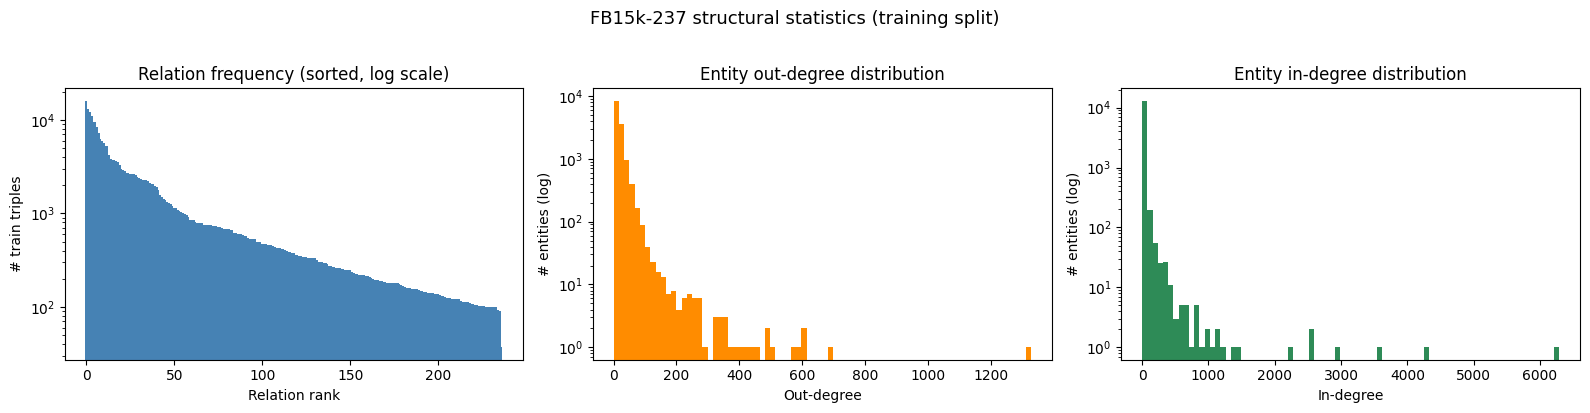

In [41]:
import matplotlib.pyplot as plt

rel_sorted = sorted(rel_counts.values(), reverse=True)
out_sorted = sorted(out_deg.values(), reverse=True)
in_sorted  = sorted(in_deg.values(), reverse=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(range(len(rel_sorted)), rel_sorted, color="steelblue", width=1)
axes[0].set_yscale("log")
axes[0].set_title("Relation frequency (sorted, log scale)")
axes[0].set_xlabel("Relation rank")
axes[0].set_ylabel("# train triples")

axes[1].hist(out_sorted, bins=80, color="darkorange", log=True, edgecolor="none")
axes[1].set_title("Entity out-degree distribution")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("# entities (log)")

axes[2].hist(in_sorted, bins=80, color="seagreen", log=True, edgecolor="none")
axes[2].set_title("Entity in-degree distribution")
axes[2].set_xlabel("In-degree")
axes[2].set_ylabel("# entities (log)")

fig.suptitle("FB15k-237 structural statistics (training split)", y=1.02, fontsize=13)
fig.tight_layout()
plt.savefig(str(ARTIFACTS / "dataset_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()


## C. Model Background

### C.1 TransE (Bordes et al., 2013)

TransE represents each entity $e$ and relation $r$ as real-valued vectors in $\mathbb{R}^d$
and treats a relation as a **translation** from head to tail:

$$f(h, r, t) = -\|\mathbf{h} + \mathbf{r} - \mathbf{t}\|_p$$

A lower distance (higher score) signals a more plausible triple. TransE is
parameter-efficient but cannot model symmetric, reflexive, or 1-to-N relations —
all common in FB15k-237.

---

### C.2 RotatE (Sun et al., 2019)

RotatE embeds entities in the **complex space** $\mathbb{C}^d$ and models each relation
as an element-wise rotation on the unit circle:

$$f(h, r, t) = -\|\mathbf{h} \circ \mathbf{r} - \mathbf{t}\|$$

where $|r_k| = 1$ for all $k$ (i.e. $r_k = e^{i\theta_k}$). This constraint is
enforced after every gradient step via `model.post_parameter_update()`. The rotation
structure lets RotatE model **symmetry** ($\theta = \pi$), **antisymmetry**,
**inversion**, and **composition** — a strict superset of what TransE can express.

---

### C.3 Self-Adversarial Negative Sampling Loss — NSSALoss (Sun et al., 2019)

Standard margin-ranking loss weights all negatives equally. NSSALoss re-weights each
negative by its current plausibility under the model, so harder negatives receive a
larger gradient signal:

$$\mathcal{L} = -\log\sigma(\gamma - f(h,r,t)) - \sum_{i=1}^{k} p_i\,\log\sigma(f(h_i',r,t_i') - \gamma)$$

$$p_i = \frac{\exp(\alpha \cdot f(h_i',r,t_i'))}{\sum_j \exp(\alpha \cdot f(h_j',r,t_j'))}$$

We use margin $\gamma = 9.0$ and adversarial temperature $\alpha = 1.0$ (RotatE paper defaults).

---

### C.4 Bernoulli Head/Tail Corruption (Wang et al., 2014)

Uniform corruption creates false negatives for 1-to-N relations (e.g. replacing the head
of a `/genre → Comedy` triple usually yields another valid triple). The Bernoulli sampler
corrupts the **head** with probability:

$$p_{\text{head}} = \frac{\text{tph}}{\text{tph} + \text{hpt}}$$

where $\text{tph}$ = average tails per head (fanout) and $\text{hpt}$ = average heads per
tail (fan-in) for that relation. High-fanout relations corrupt the head more — where fewer
valid alternatives exist — producing cleaner negatives.


## D. Configuration

These constants are shared by all training scripts and interpolated into the `!python …`
shell calls below. They mirror the CLI flags of `train_baseline_kge.py` and
`train_rotate_custom.py` exactly, so the notebook and the scripts are always in sync.


In [42]:
# ── Shared hyper-parameters (all 7 runs) ─────────────────────────────────────
DIM                     = 128       # embedding dimension
BATCH_SIZE              = 1024
LR                      = 1e-3
EPOCHS                  = 50        # max epochs; early stopping may trigger earlier
PATIENCE                = 10        # early-stopping patience (val MRR)
SEED                    = 42
MARGIN                  = 9.0       # NSSALoss margin (RotatE paper default)
ADVERSARIAL_TEMPERATURE = 1.0       # NSSALoss adversarial temperature
NUM_NEGS                = 8         # negatives per positive triple

# ── Custom-pipeline-only parameters ───────────────────────────────────────────
POOL_SIZE               = 64        # Stage 1 candidate pool size (n)
SMOKE_STRATEGY          = "mixed"   # strategy used in the smoke test
SMOKE_HARD_FRACTION     = 0.5       # hard fraction used in smoke test

print(
    f"loss=NSSALoss(margin={MARGIN}, adv_temp={ADVERSARIAL_TEMPERATURE}) | "
    f"sampler=bernoulli(filtered, num_negs={NUM_NEGS}) | "
    f"d={DIM} bs={BATCH_SIZE} lr={LR} epochs={EPOCHS} patience={PATIENCE} seed={SEED}"
)
print(f"Custom pipeline: pool_size={POOL_SIZE}, smoke_strategy={SMOKE_STRATEGY}, "
      f"smoke_hard_fraction={SMOKE_HARD_FRACTION}")


loss=NSSALoss(margin=9.0, adv_temp=1.0) | sampler=bernoulli(filtered, num_negs=8) | d=128 bs=1024 lr=0.001 epochs=50 patience=10 seed=42
Custom pipeline: pool_size=64, smoke_strategy=mixed, smoke_hard_fraction=0.5


## E. Baselines — TransE and RotatE (≈ 80 min total on T4)

We trained TransE and RotatE using PyKEEN's `pipeline()` with our unified
configuration (`NSSALoss`, Bernoulli filtered sampler, 8 negatives per positive).
Results are written to `artifacts/baseline/`.

The training commands are commented out because the checkpoints already exist.
Uncomment to retrain from scratch.


In [43]:
# Uncomment to retrain the baselines (~40 min each on T4).

# !python code/train_baseline_kge.py --model TransE \
#     --epochs {EPOCHS} --batch_size {BATCH_SIZE} --lr {LR} --dim {DIM} \
#     --patience {PATIENCE} --margin {MARGIN} \
#     --adversarial-temperature {ADVERSARIAL_TEMPERATURE} --num-negs {NUM_NEGS}

# !python code/train_baseline_kge.py --model RotatE \
#     --epochs {EPOCHS} --batch_size {BATCH_SIZE} --lr {LR} --dim {DIM} \
#     --patience {PATIENCE} --margin {MARGIN} \
#     --adversarial-temperature {ADVERSARIAL_TEMPERATURE} --num-negs {NUM_NEGS}


### E.1 Baseline results

In [44]:
import re, pandas as pd
from pathlib import Path
from IPython.display import display

def parse_baseline_summary(path: Path) -> dict:
    """Parse a baseline summary.txt → dict of metric name → value."""
    text  = path.read_text()
    lines = text.strip().split("\n")
    d = {}
    for kv in lines[0].split():             # header: key=value pairs
        if "=" in kv:
            k, v = kv.split("=", 1)
            d[k] = v
    for line in lines[1:]:                   # body: metric: value
        m = re.match(r"^([\w\.]+):\s+([\d\.]+)", line.strip())
        if m:
            d[m.group(1)] = float(m.group(2))
    return d

baseline_dir = ARTIFACTS / "baseline"
rows = []
for model_name in ["TransE", "RotatE"]:
    p = baseline_dir / f"{model_name}_summary.txt"
    if not p.exists():
        print(f"Missing: {p}  — uncomment and run the training cell above.")
        continue
    d = parse_baseline_summary(p)
    rows.append({
        "Model":    f"Baseline {model_name}",
        "MRR":      d.get("both.realistic.inverse_harmonic_mean_rank"),
        "H@1":      d.get("both.realistic.hits_at_1"),
        "H@3":      d.get("both.realistic.hits_at_3"),
        "H@10":     d.get("both.realistic.hits_at_10"),
        "MRR head": d.get("head.realistic.inverse_harmonic_mean_rank"),
        "MRR tail": d.get("tail.realistic.inverse_harmonic_mean_rank"),
    })

baseline_df = pd.DataFrame(rows).set_index("Model") if rows else pd.DataFrame()
display(baseline_df.round(4))


,MRR,H@1,H@3,H@10,MRR head,MRR tail
Model,,,,,,
Baseline TransE,0.2790,0.1879,0.3115,0.4594,0.1839,0.3740
Baseline RotatE,0.2765,0.1935,0.3081,0.4379,0.1738,0.3792


### E.2 Baseline learning curves

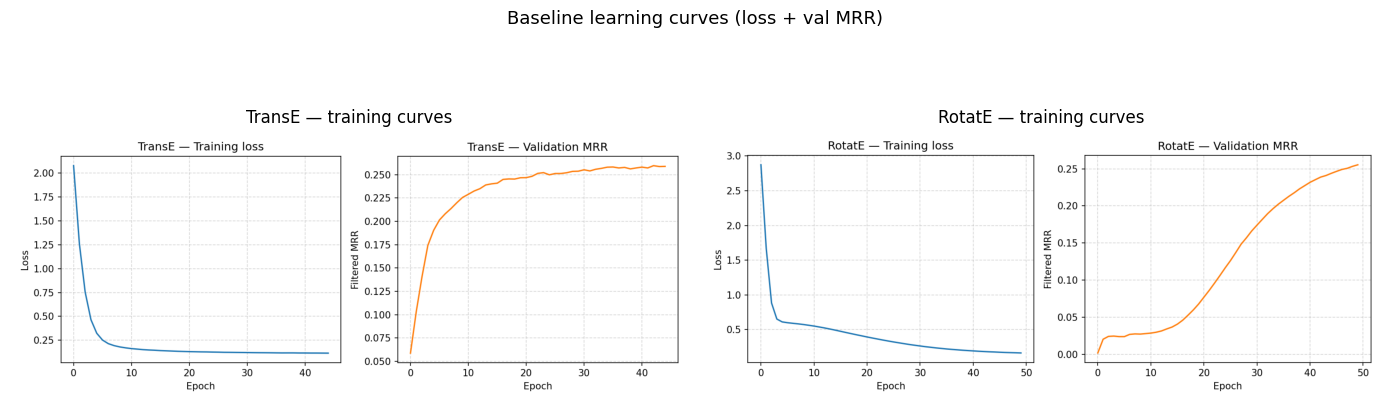

In [45]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model_name in zip(axes, ["TransE", "RotatE"]):
    png = baseline_dir / f"{model_name}_curves.png"
    if png.exists():
        img = mpimg.imread(str(png))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{model_name} — training curves", fontsize=12)
    else:
        ax.text(0.5, 0.5, f"{model_name}_curves.png\nnot found",
                ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
plt.suptitle("Baseline learning curves (loss + val MRR)", fontsize=13)
plt.tight_layout()
plt.show()


## F. Custom Two-Stage Negative Sampling Pipeline

Our contribution replaces PyKEEN's default sampler with a **two-stage pipeline**
implemented across three small, independently testable modules:

```
For each positive triple (h, r, t) in a mini-batch:

  ┌─ Stage 1: Pool generation ─────────────────────────────────────┐
  │  1a. Draw corruption side (head or tail) via Bernoulli(p_r)    │
  │  1b. Sample a pool of n = 64 unique filtered candidates        │
  │      (none appear as known-true in the training graph)         │
  └────────────────────────────────────────────────────────────────┘
               │  pool of n clean negatives
               ▼
  ┌─ Stage 2: Selection ───────────────────────────────────────────┐
  │  2a. Score all n candidates with the current model             │
  │  2b. Select k = 8 final negatives via one of:                  │
  │       • random — uniform random draw from pool                 │
  │       • hard   — top-k by score (most plausible = hardest)     │
  │       • mixed  — Binomial(k, p) hard + remainder random        │
  └────────────────────────────────────────────────────────────────┘
```

This design **decouples exploration** (large filtered pool) from **exploitation**
(strategy-driven selection). The model, loss, and all other hyper-parameters are
identical across strategies — only the sampler changes.


### F.1 Stage 1 — Bernoulli corruption + filtering (`negative_sampling.py`)

In [46]:
import inspect, sys
sys.path.insert(0, str(CODE))

from negative_sampling import compute_bernoulli_probs, generate_candidates

print("─── compute_bernoulli_probs ───")
print(inspect.getsource(compute_bernoulli_probs))


─── compute_bernoulli_probs ───
def compute_bernoulli_probs(
    mapped_triples: np.ndarray,
    num_relations: int,
) -> BernoulliCorruptionProbs:
    """Compute head-corruption probabilities as in PyKEEN's BernoulliNegativeSampler."""
    triples = mapped_triples.astype(np.int64, copy=False)
    corrupt_head_probability = np.zeros(num_relations, dtype=np.float64)

    head_rel_pairs, tail_counts = np.unique(triples[:, :2], axis=0, return_counts=True)
    rel_tail_pairs, head_counts = np.unique(triples[:, 1:], axis=0, return_counts=True)

    for relation in range(num_relations):
        tail_mask = head_rel_pairs[:, 1] == relation
        head_mask = rel_tail_pairs[:, 0] == relation

        tph = tail_counts[tail_mask].astype(np.float64).mean() if tail_mask.any() else 0.0
        hpt = head_counts[head_mask].astype(np.float64).mean() if head_mask.any() else 0.0

        if tph + hpt == 0.0:
            corrupt_head_probability[relation] = 0.5
        else:
            corrupt_head_p

In [47]:
print("─── generate_candidates ───")
print(inspect.getsource(generate_candidates))


─── generate_candidates ───
def generate_candidates(
    head: int,
    relation: int,
    tail: int,
    *,
    n: int,
    side: CorruptionSide,
    num_entities: int,
    triple_index: TrainTripleIndex,
    rng: np.random.Generator,
    max_attempts_per_candidate: int = 100,
) -> list[tuple[int, int, int]]:
    """Generate n unique filtered negative candidates on a fixed corruption side."""
    if n <= 0:
        raise ValueError("n must be positive")

    positive = (int(head), int(relation), int(tail))
    candidates: list[tuple[int, int, int]] = []
    seen: set[tuple[int, int, int]] = set()
    max_attempts = n * max_attempts_per_candidate
    attempts = 0

    while len(candidates) < n and attempts < max_attempts:
        attempts += 1
        candidate = corrupt_once(head, relation, tail, side, num_entities, rng)
        if candidate == positive or candidate in seen or triple_index.contains(*candidate):
            continue
        seen.add(candidate)
        candidates.append

### F.2 Stage 2 — Selection strategies (`select_candidates.py`)

| Strategy | Description | Trade-off |
|----------|-------------|-----------|
| **random** | Uniform random draw from pool | Maximum diversity; equivalent to standard filtered sampling |
| **hard** | Top-k by model score | Maximum gradient signal; less diversity |
| **mixed** | Binomial(k, p) hard + remainder random | Tunes exploration/exploitation; p = `hard_fraction` |

The **Binomial split** in mixed mode means each of the k slots is independently
hard with probability p. For k = 1 this is a coin-flip — the correct expected
mix even at the single-triple level — rather than a deterministic rounding that
would always favour one strategy.


In [48]:
from select_candidates import select_hard, select_mixed

print("─── select_hard ───")
print(inspect.getsource(select_hard))
print()
print("─── select_mixed ───")
print(inspect.getsource(select_mixed))


─── select_hard ───
def select_hard(
    ranked: list[RankedCandidate],
    k: int,
) -> list[tuple[int, int, int]]:
    """Pick the k highest-scored (hardest) negatives."""
    if k <= 0:
        raise ValueError("k must be positive")
    if k > len(ranked):
        raise ValueError(f"Cannot select k={k} negatives from a pool of size {len(ranked)}.")

    return [item.triple for item in ranked[:k]]


─── select_mixed ───
def select_mixed(
    candidates: list[tuple[int, int, int]],
    ranked: list[RankedCandidate],
    k: int,
    rng: np.random.Generator,
    *,
    hard_fraction: float = 0.5,
) -> list[tuple[int, int, int]]:
    """Pick a mix of random and hard negatives (default 50/50).

    Uses a Binomial draw rather than deterministic rounding so that k=1
    still produces the correct *expected* mix over many positives: e.g.
    hard_fraction=0.5 picks hard 50 % of the time and random 50 % of the
    time, instead of always rounding to one or the other.
    """
    if k <= 0:


### F.3 End-to-end demo

In [49]:
import numpy as np, torch

# Use any available checkpoint; skip gracefully if none found yet.
_ckpt = next((ARTIFACTS / "custom").rglob("trained_model.pkl"), None)         if (ARTIFACTS / "custom").exists() else None

if _ckpt is None:
    print("No checkpoint found — run Section G (smoke) or H (full training) first, then re-run.")
else:
    from negative_sampling import build_sampling_context, choose_corruption_side, generate_candidates
    from score_candidates import score_triples, rank_candidates
    from select_candidates import SelectionStrategy, select_negatives

    _device = "cuda" if torch.cuda.is_available() else "cpu"
    _model  = torch.load(_ckpt, map_location=_device, weights_only=False)
    _model.eval()

    _idx, _bern, _n_ent = build_sampling_context(dataset.training)
    _rng = np.random.default_rng(99)
    _triple = dataset.training.mapped_triples.numpy()[_rng.integers(len(dataset.training.mapped_triples))]
    _h, _r, _t = map(int, _triple)
    print(f"Positive : (h={_h}, r='{dataset.training.relation_id_to_label[_r]}', t={_t})")

    # Stage 1
    _side = choose_corruption_side(_r, _rng, _bern)
    _pool = generate_candidates(_h, _r, _t, n=64, side=_side,
                                num_entities=_n_ent, triple_index=_idx, rng=_rng)
    _scores = score_triples(_model, _pool, device=_device)
    print(f"\nSide : {_side.value}  (p_head={_bern.corrupt_head_probability[_r]:.3f})")
    print(f"Pool : {len(_pool)} candidates  |  score range [{_scores.min():.3f}, {_scores.max():.3f}]")

    # Stage 2 — compare all three strategies side-by-side
    _ranked = rank_candidates(_pool, _scores)
    _hard   = select_negatives(SelectionStrategy.HARD,   _pool, _scores, k=8, rng=_rng)
    _rand   = select_negatives(SelectionStrategy.RANDOM, _pool, _scores, k=8, rng=_rng)

    print("\n─── Hard (top-8 by score) ───")
    for rc in _ranked[:8]:
        print(f"  {rc.triple}  score={rc.score:.3f}")
    print("\n─── Random (8 uniform draws) ───")
    for tri in _rand:
        print(f"  {tri}  score={_scores[_pool.index(tri)]:.3f}")


Positive : (h=13475, r='/music/group_member/membership./music/group_membership/role', t=5611)

Side : tail  (p_head=0.187)
Pool : 64 candidates  |  score range [-14.233, -11.350]

─── Hard (top-8 by score) ───
  (13475, 152, 9984)  score=-11.350
  (13475, 152, 7340)  score=-11.775
  (13475, 152, 1000)  score=-12.193
  (13475, 152, 8919)  score=-12.244
  (13475, 152, 8518)  score=-12.258
  (13475, 152, 13997)  score=-12.271
  (13475, 152, 1543)  score=-12.360
  (13475, 152, 1313)  score=-12.412

─── Random (8 uniform draws) ───
  (13475, 152, 9045)  score=-13.114
  (13475, 152, 13997)  score=-12.271
  (13475, 152, 11236)  score=-13.323
  (13475, 152, 8849)  score=-12.748
  (13475, 152, 13155)  score=-12.543
  (13475, 152, 1328)  score=-13.795
  (13475, 152, 4970)  score=-12.985
  (13475, 152, 8919)  score=-12.244


## G. Smoke Test (~2 min on GPU)

Runs 10 mini-batches and evaluates on 200 validation triples to confirm the full
pipeline — candidate generation → scoring → selection → NSSALoss → backward →
`post_parameter_update` — executes without errors. The resulting MRR will be near
zero; that is expected for a 10-batch, 1-epoch run.

`--run-label RotatE_smoke` writes output to `artifacts/custom/RotatE_smoke/`
so it **never overwrites a real reported checkpoint**.

In [50]:
!python code/train_rotate_custom.py \
    --strategy {SMOKE_STRATEGY} \
    --hard-fraction {SMOKE_HARD_FRACTION} \
    --num-negs {NUM_NEGS} \
    --pool-size {POOL_SIZE} \
    --epochs 1 \
    --batch-size 256 \
    --margin {MARGIN} \
    --adversarial-temperature {ADVERSARIAL_TEMPERATURE} \
    --seed {SEED} \
    --limit-batches 10 \
    --limit-val-eval 200 \
    --run-label RotatE_smoke

Note: RotatE requires complex ops — falling back to CPU.
Loading FB15k-237 ...
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
Training RotatE | strategy=mixed | d=128 | bs=256 | pool=64 | num_negs=8 | lr=0.001 | loss=NSSALoss(margin=9.0, adv_temp=1.0) | sampler=bernoulli_filtered | max_epochs=1 | patience=10 | device=cpu | hard_fraction=0.5
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples were filtered out
Evaluating on cpu:   0%|                         | 0.00/200 [00:00<?, ?triple/s]Encountered tensors on device_types={'cpu'} while only ['cuda'] are considered safe for automatic memory utilization maximization. This may lead to undocumented crashes (but can be safe, too).
Evaluating on cpu: 100%|███████████████████| 

## H. Full Custom Training (5 strategies × 50 epochs, ≈ 4–5 h on T4)

These are the **exact commands** used to produce our reported numbers. Each run
writes its artefacts to `artifacts/custom/RotatE_<label>/`:

| File | Contents |
|------|----------|
| `summary.txt` | Final test metrics (MRR, H@1, H@3, H@10) |
| `history.json` | Per-epoch training loss and validation MRR |
| `curves.png` | Learning-curve plot |
| `trained_model.pkl` | Serialised PyTorch model |

Do **not** run `git pull` between two runs you want to compare directly.


In [51]:
# Uncomment the run(s) you want to reproduce.

# !python code/train_rotate_custom.py --strategy random \
#     --num-negs {NUM_NEGS} --pool-size {POOL_SIZE} --epochs {EPOCHS} --patience {PATIENCE}

# !python code/train_rotate_custom.py --strategy hard \
#     --num-negs {NUM_NEGS} --pool-size {POOL_SIZE} --epochs {EPOCHS} --patience {PATIENCE}

# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.3 \
#     --num-negs {NUM_NEGS} --pool-size {POOL_SIZE} --epochs {EPOCHS} --patience {PATIENCE}

# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.5 \
#     --num-negs {NUM_NEGS} --pool-size {POOL_SIZE} --epochs {EPOCHS} --patience {PATIENCE}

# !python code/train_rotate_custom.py --strategy mixed --hard-fraction 0.7 \
#     --num-negs {NUM_NEGS} --pool-size {POOL_SIZE} --epochs {EPOCHS} --patience {PATIENCE}


## I. Training Results

We load `history.json` from every completed custom run to visualise learning dynamics,
then consolidate the final test metrics into a single comparison table across all
7 models (2 baselines + 5 custom strategies).


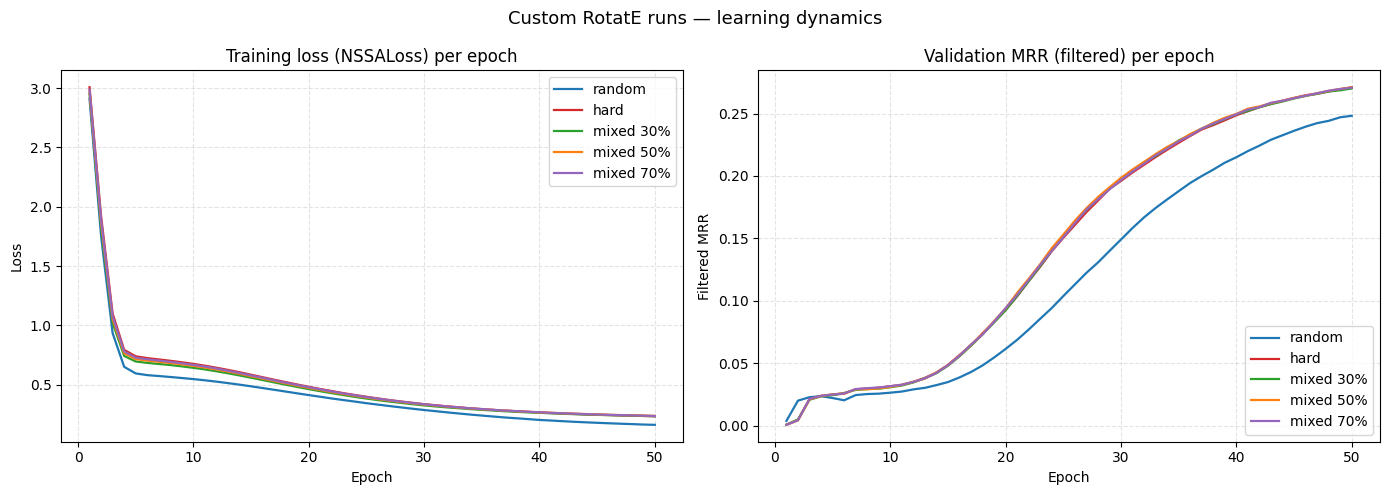

In [52]:
import json, matplotlib.pyplot as plt

custom_dir = ARTIFACTS / "custom"

RUN_META = {                         # dir name → (display label, line color)
    "RotatE_random":      ("random",    "tab:blue"),
    "RotatE_hard":        ("hard",      "tab:red"),
    "RotatE_mixed_30_70": ("mixed 30%", "tab:green"),
    "RotatE_mixed_50_50": ("mixed 50%", "tab:orange"),
    "RotatE_mixed_70_30": ("mixed 70%", "tab:purple"),
}

fig, (ax_loss, ax_val) = plt.subplots(1, 2, figsize=(14, 5))
histories = {}

for run_dir, (label, color) in RUN_META.items():
    hp = custom_dir / run_dir / "history.json"
    if not hp.exists():
        continue
    h = json.load(hp.open())
    histories[run_dir] = h
    losses   = h.get("losses", [])
    val_mrrs = h.get("val_mrrs", [])
    if losses:
        ax_loss.plot(range(1, len(losses)+1), losses,
                     label=label, color=color, linewidth=1.6)
    if val_mrrs:
        ax_val.plot(range(1, len(val_mrrs)+1), val_mrrs,
                    label=label, color=color, linewidth=1.6)

ax_loss.set_title("Training loss (NSSALoss) per epoch")
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
ax_loss.legend(loc="upper right"); ax_loss.grid(True, linestyle="--", alpha=0.35)

ax_val.set_title("Validation MRR (filtered) per epoch")
ax_val.set_xlabel("Epoch"); ax_val.set_ylabel("Filtered MRR")
ax_val.legend(loc="lower right"); ax_val.grid(True, linestyle="--", alpha=0.35)

fig.suptitle("Custom RotatE runs — learning dynamics", fontsize=13)
fig.tight_layout()
plt.savefig(str(ARTIFACTS / "custom_learning_curves.png"), dpi=150)
plt.show()

if not histories:
    print("No history.json files found — run full training (Section H) first.")


In [53]:
import re, pandas as pd
from IPython.display import display

# Baseline numbers hard-coded from artifacts/baseline/*_summary.txt
BASELINE_ROWS = [
    {"Model": "Baseline TransE", "Strategy": "—", "Source": "PyKEEN pipeline",
     "MRR": 0.2790, "H@1": 0.1879, "H@3": 0.3115, "H@10": 0.4594,
     "MRR head": 0.1839, "MRR tail": 0.3740},
    {"Model": "Baseline RotatE", "Strategy": "—", "Source": "PyKEEN pipeline",
     "MRR": 0.2765, "H@1": 0.1935, "H@3": 0.3081, "H@10": 0.4379,
     "MRR head": 0.1738, "MRR tail": 0.3792},
]

RUN_DISPLAY = {
    "RotatE_random":      ("Custom random",    "random"),
    "RotatE_hard":        ("Custom hard",      "hard"),
    "RotatE_mixed_30_70": ("Custom mixed 30%", "mixed"),
    "RotatE_mixed_50_50": ("Custom mixed 50%", "mixed"),
    "RotatE_mixed_70_30": ("Custom mixed 70%", "mixed"),
}

def _parse_custom(path):
    d = {}
    for line in path.read_text().strip().split("\n"):
        m = re.match(r"^([\w@_]+):\s+([\d.]+)", line.strip())
        if m:
            d[m.group(1)] = float(m.group(2))
    return d

rows = list(BASELINE_ROWS)
for run_dir, (display_name, strategy) in RUN_DISPLAY.items():
    sp = custom_dir / run_dir / "summary.txt"
    if not sp.exists():
        continue
    d = _parse_custom(sp)
    rows.append({
        "Model":    display_name, "Strategy": strategy, "Source": "Custom pipeline",
        "MRR":      d.get("test_mrr"),    "H@1":  d.get("test_hits_at_1"),
        "H@3":      d.get("test_hits_at_3"), "H@10": d.get("test_hits_at_10"),
        "MRR head": None,                 "MRR tail": None,
    })

results_df = pd.DataFrame(rows).set_index("Model")
display(results_df.round(4).style.highlight_max(
    subset=["MRR", "H@1", "H@3", "H@10"], color="lightgreen", axis=0
))

custom_mask = results_df["Source"] == "Custom pipeline"
if custom_mask.any():
    best_custom = results_df.loc[custom_mask, "MRR"].max()
    best_base   = results_df.loc[~custom_mask, "MRR"].max()
    print(f"\nBest custom MRR   : {best_custom:.4f}")
    print(f"Best baseline MRR : {best_base:.4f}")
    print(f"Delta             : {best_custom - best_base:+.4f}")


,Strategy,Source,MRR,H@1,H@3,H@10,MRR head,MRR tail
Model,,,,,,,,
Baseline TransE,—,PyKEEN pipeline,0.279000,0.187900,0.311500,0.459400,0.183900,0.374000
Baseline RotatE,—,PyKEEN pipeline,0.276500,0.193500,0.308100,0.437900,0.173800,0.379200
Custom random,random,Custom pipeline,0.270200,0.189400,0.300400,0.428000,nan,nan
Custom hard,hard,Custom pipeline,0.298200,0.217400,0.326800,0.458800,nan,nan
Custom mixed 30%,mixed,Custom pipeline,0.296800,0.214800,0.326200,0.459200,nan,nan
Custom mixed 50%,mixed,Custom pipeline,0.298200,0.216100,0.328200,0.460300,nan,nan
Custom mixed 70%,mixed,Custom pipeline,0.298500,0.216500,0.328300,0.460700,nan,nan



Best custom MRR   : 0.2985
Best baseline MRR : 0.2790
Delta             : +0.0195


## J. Slice Evaluation

Global metrics hide where a model succeeds or fails. We partition the test set along
three axes — all derived from the **training split only** (no leakage) — and compute
filtered MRR per partition.

| Axis | low | mid | high |
|------|-----|-----|------|
| Relation frequency | rare relations | medium | frequent |
| Head out-degree | few outgoing edges | medium | hub entities |
| Tail in-degree | few incoming edges | medium | hub entities |

**Tertile (33rd/67th percentile) cuts** define the three buckets, computed once and
cached in `artifacts/slice_buckets.json` so every model sees the same partition.


In [54]:
# OPTIONAL — slices.json files are already committed to git for all 5 custom models,
# so the tables and plots below will work without re-running this.
# Re-run only if you retrained a checkpoint or want to add baseline models.
# Warning: evaluating all checkpoints takes ~10–15 min per model on a T4 GPU.
!python code/evaluate_slices.py --all

Note: RotatE complex ops not supported on MPS — falling back to CPU.
Found 6 checkpoint(s): ['artifacts/custom/RotatE_hard/trained_model.pkl', 'artifacts/custom/RotatE_mixed_30_70/trained_model.pkl', 'artifacts/custom/RotatE_mixed_50_50/trained_model.pkl', 'artifacts/custom/RotatE_mixed_70_30/trained_model.pkl', 'artifacts/custom/RotatE_random/trained_model.pkl', 'artifacts/custom/RotatE_smoke/trained_model.pkl']

=== Slicing artifacts/custom/RotatE_hard/trained_model.pkl ===
Loading FB15k-237 ...
You're trying to map triples with 30 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 28 from 20466 triples were filtered out
Loading model from /Users/rafaelgufler/Documents/development/dl_kg_project/artifacts/custom/RotatE_hard/trained_model.pkl ...
You're trying to map triples with 9 entities and 0 relations that are not in the training set. These triples will be excluded from the mapping.
In total 9 from 17535 triples wer

In [55]:
import json, pandas as pd
from pathlib import Path
from IPython.display import display

AXIS_LABELS = {
    "relation_frequency": "Relation frequency",
    "head_degree":        "Head out-degree",
    "tail_degree":        "Tail in-degree",
}
MODEL_ORDER = [
    "custom/RotatE_random",
    "custom/RotatE_hard",
    "custom/RotatE_mixed_30_70",
    "custom/RotatE_mixed_50_50",
    "custom/RotatE_mixed_70_30",
]
MODEL_LABELS = {
    "custom/RotatE_random":      "random",
    "custom/RotatE_hard":        "hard",
    "custom/RotatE_mixed_30_70": "mixed 30%",
    "custom/RotatE_mixed_50_50": "mixed 50%",
    "custom/RotatE_mixed_70_30": "mixed 70%",
}

# Load all slices.json — exclude backup and smoke-test dirs
slice_data = {}
for p in sorted(Path("artifacts").rglob("slices.json")):
    posix = p.as_posix()
    if "baseline_old_" in posix:
        continue
    key = str(p.parent.relative_to("artifacts"))
    slice_data[key] = json.load(p.open())

if not slice_data:
    print("No slices.json found — run the cell above first.")
else:
    # ── Global table ──────────────────────────────────────────────────
    g_rows = []
    for key in MODEL_ORDER:
        if key not in slice_data:
            continue
        g = slice_data[key]["global"]
        g_rows.append({
            "Model":    MODEL_LABELS[key], "n": g["n"],
            "MRR":      round(g["mrr"], 4),      "H@1":  round(g["hits_at_1"], 4),
            "H@3":      round(g["hits_at_3"], 4), "H@10": round(g["hits_at_10"], 4),
            "MRR head": round(g["mrr_head"], 4),  "MRR tail": round(g["mrr_tail"], 4),
        })
    gdf = pd.DataFrame(g_rows).set_index("Model")
    print("=== Global test-set metrics ===")
    display(gdf.style.highlight_max(
        subset=["MRR","H@1","H@3","H@10","MRR head","MRR tail"],
        color="lightgreen", axis=0))


=== Global test-set metrics ===


,n,MRR,H@1,H@3,H@10,MRR head,MRR tail
Model,,,,,,,
random,20438,0.270200,0.189400,0.300400,0.428000,0.169200,0.371300
hard,20438,0.298200,0.217400,0.326800,0.458800,0.193900,0.402500
mixed 30%,20438,0.296800,0.214800,0.326200,0.459200,0.192200,0.401300
mixed 50%,20438,0.298200,0.216100,0.328200,0.460300,0.194500,0.401900
mixed 70%,20438,0.298500,0.216500,0.328300,0.460700,0.195200,0.401700


In [56]:
# ── Per-axis MRR tables ───────────────────────────────────────────────────────
for axis, axis_label in AXIS_LABELS.items():
    ax_rows = []
    for key in MODEL_ORDER:
        if key not in slice_data:
            continue
        row = {"Model": MODEL_LABELS[key]}
        for bucket in ("low", "mid", "high"):
            entry = slice_data[key].get(axis, {}).get(bucket, {})
            n = entry.get("n", 0)
            row[f"{bucket} (n={n})"] = round(entry.get("mrr") or 0, 4) if n > 0 else None
        ax_rows.append(row)
    if ax_rows:
        df_ax = pd.DataFrame(ax_rows).set_index("Model")
        print(f"\n=== MRR by {axis_label} ===")
        display(df_ax.style.highlight_max(color="lightgreen", axis=0))



=== MRR by Relation frequency ===


,low (n=849),mid (n=2172),high (n=17417)
Model,,,
random,0.382100,0.332000,0.257100
hard,0.417600,0.362400,0.284400
mixed 30%,0.417600,0.361800,0.282800
mixed 50%,0.414400,0.362800,0.284500
mixed 70%,0.416000,0.362200,0.284800



=== MRR by Head out-degree ===


,low (n=1810),mid (n=5664),high (n=12914)
Model,,,
random,0.262500,0.250500,0.275800
hard,0.284700,0.268200,0.307500
mixed 30%,0.283400,0.267400,0.305900
mixed 50%,0.284300,0.269200,0.306800
mixed 70%,0.283000,0.267800,0.308300



=== MRR by Tail in-degree ===


,low (n=1478),mid (n=3029),high (n=15849)
Model,,,
random,0.157000,0.154100,0.301300
hard,0.186700,0.175400,0.329800
mixed 30%,0.186400,0.174200,0.328300
mixed 50%,0.185200,0.173400,0.330600
mixed 70%,0.187800,0.174600,0.330300


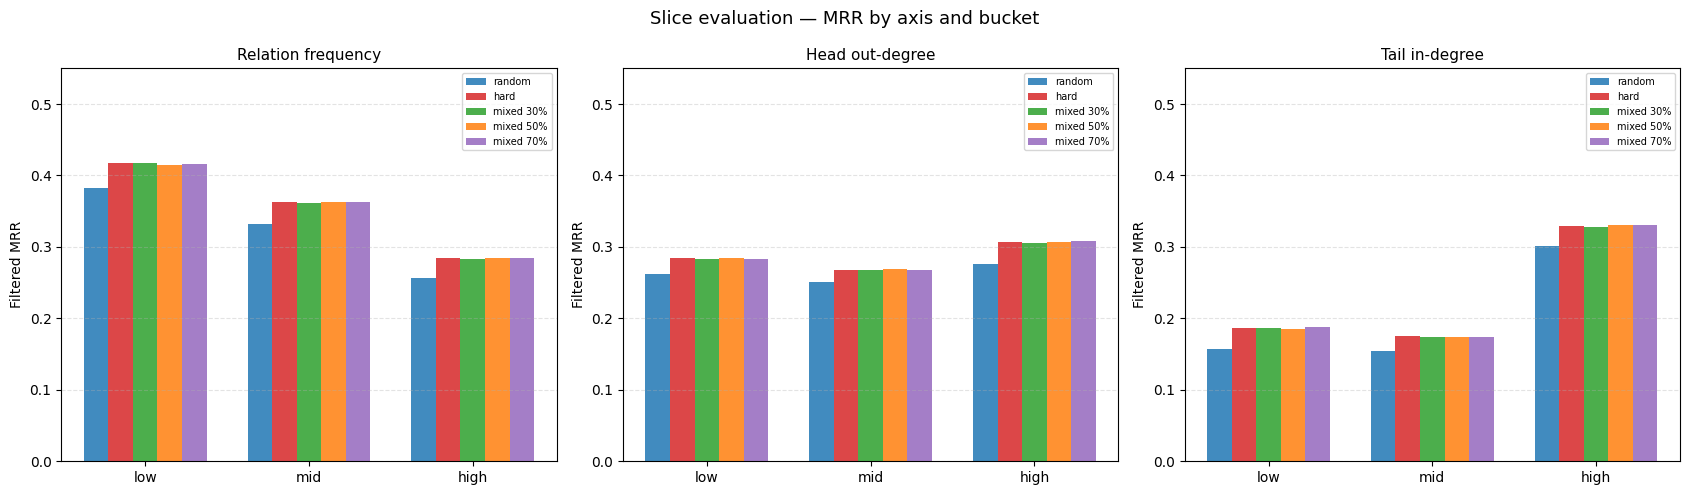

In [ ]:
import matplotlib.pyplot as plt, numpy as np

if slice_data:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    colors  = ["tab:blue", "tab:red", "tab:green", "tab:orange", "tab:purple"]
    present = [k for k in MODEL_ORDER if k in slice_data]

    for ax, (axis, axis_label) in zip(axes, AXIS_LABELS.items()):
        x = np.arange(3)
        w = 0.15
        for i, key in enumerate(present):
            vals = [slice_data[key].get(axis, {}).get(b, {}).get("mrr") or 0
                    for b in ("low", "mid", "high")]
            ax.bar(x + i*w, vals, w, label=MODEL_LABELS[key],
                   color=colors[i], alpha=0.85)
        ax.set_xticks(x + w*(len(present)-1)/2)
        ax.set_xticklabels(["low", "mid", "high"])
        ax.set_title(axis_label, fontsize=11)
        ax.set_ylabel("Filtered MRR")
        ax.set_ylim(0, 0.55)
        ax.legend(fontsize=7)
        ax.grid(axis="y", linestyle="--", alpha=0.35)

    fig.suptitle("Slice evaluation — MRR by axis and bucket", fontsize=13)
    fig.tight_layout()
    plt.savefig(str(ARTIFACTS / "slice_bar_plots.png"), dpi=150)
    plt.show()


## K. Qualitative Analysis

For a sample of 5 test triples we inspect exactly what each model predicts.
`qualitative_examples.py` computes the **filtered rank** of the correct entity on
both sides (head and tail corruption) and lists the top-10 candidates after masking
all known-true triples from train + val + test.

Side-by-side comparison reveals cases where hard-negative training pushes the gold
entity from rank 50 to rank 1 — and cases where even the best model fails.


In [ ]:
# OPTIONAL — artifacts/qualitative.md is already committed to git,
# so the display cell below will work without re-running this.
# Re-run only if you retrained a checkpoint or want fresh predictions.
# Note: baseline pkl files (pykeen_TransE, pykeen_RotatE) must exist to include baselines.
!python code/qualitative_examples.py --num-triples 5 --top-k 10

In [57]:
from IPython.display import Markdown
from pathlib import Path

qual_path = ARTIFACTS / "qualitative.md"
if qual_path.exists():
    lines = qual_path.read_text().splitlines()
    display(Markdown("\n".join(lines[:160])))
    if len(lines) > 160:
        print(f"\n... ({len(lines)-160} more lines) — see artifacts/qualitative.md for the full report.")
else:
    print("qualitative.md not found — run the cell above first.")


# Qualitative predictions on FB15k-237

_Sampled 5 test triples (seed=42). Top-10 candidates per side, filtered against the train+val+test triples._

## Triple 1: (/m/0btyf5z, /film/film/release_date_s./film/film_regional_release_date/film_release_region, /m/0345h)

### artifacts/baseline/pykeen_TransE/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **2**
  - `/m/09c7w0` (score=-6.095)
  - `/m/0345h` (score=-6.393) ←gold
  - `/m/0chghy` (score=-6.685)
  - `/m/01mjq` (score=-6.828)
  - `/m/03rt9` (score=-6.839)
  - `/m/03_3d` (score=-6.954)
  - `/m/0154j` (score=-7.042)
  - `/m/035qy` (score=-7.044)
  - `/m/06mkj` (score=-7.050)
  - `/m/05v8c` (score=-7.050)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **31**
  - `/m/03yvf2` (score=-5.305)
  - `/m/0mbql` (score=-5.373)
  - `/m/0gvvm6l` (score=-5.407)
  - `/m/04yg13l` (score=-5.433)
  - `/m/032clf` (score=-5.452)
  - `/m/0m3gy` (score=-5.579)
  - `/m/0bs8hvm` (score=-5.643)
  - `/m/0184tc` (score=-5.682)
  - `/m/0m491` (score=-5.723)
  - `/m/0h21v2` (score=-5.801)

### artifacts/baseline/pykeen_RotatE/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **3**
  - `/m/0jgd` (score=-6.800)
  - `/m/06mkj` (score=-6.823)
  - `/m/0345h` (score=-6.893) ←gold
  - `/m/0154j` (score=-6.933)
  - `/m/015fr` (score=-6.941)
  - `/m/035qy` (score=-6.999)
  - `/m/0chghy` (score=-7.048)
  - `/m/03_3d` (score=-7.069)
  - `/m/03spz` (score=-7.070)
  - `/m/05qhw` (score=-7.121)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **48**
  - `/m/049w1q` (score=-5.873)
  - `/m/03yvf2` (score=-5.927)
  - `/m/09gmmt6` (score=-5.975)
  - `/m/0gh65c5` (score=-6.205)
  - `/m/0gvvm6l` (score=-6.301)
  - `/m/0gvvf4j` (score=-6.302)
  - `/m/09146g` (score=-6.442)
  - `/m/01shy7` (score=-6.449)
  - `/m/0gfh84d` (score=-6.450)
  - `/m/0432_5` (score=-6.521)

### artifacts/custom/RotatE_random/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **9**
  - `/m/0jgd` (score=-6.271)
  - `/m/035qy` (score=-6.282)
  - `/m/05b4w` (score=-6.330)
  - `/m/03rj0` (score=-6.335)
  - `/m/06mkj` (score=-6.344)
  - `/m/03_3d` (score=-6.404)
  - `/m/0chghy` (score=-6.410)
  - `/m/0154j` (score=-6.414)
  - `/m/0345h` (score=-6.415) ←gold
  - `/m/05v8c` (score=-6.419)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **19**
  - `/m/09gmmt6` (score=-5.844)
  - `/m/0gh65c5` (score=-5.950)
  - `/m/049w1q` (score=-5.952)
  - `/m/03yvf2` (score=-6.000)
  - `/m/0m491` (score=-6.117)
  - `/m/01xlqd` (score=-6.183)
  - `/m/0gvvm6l` (score=-6.195)
  - `/m/01shy7` (score=-6.252)
  - `/m/08j7lh` (score=-6.286)
  - `/m/02pxst` (score=-6.304)

### artifacts/custom/RotatE_hard/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **1**
  - `/m/0345h` (score=-7.358) ←gold
  - `/m/06mkj` (score=-7.408)
  - `/m/03_3d` (score=-7.445)
  - `/m/0jgd` (score=-7.478)
  - `/m/05qhw` (score=-7.497)
  - `/m/015fr` (score=-7.509)
  - `/m/0chghy` (score=-7.519)
  - `/m/035qy` (score=-7.520)
  - `/m/05b4w` (score=-7.574)
  - `/m/0154j` (score=-7.603)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **19**
  - `/m/03yvf2` (score=-6.776)
  - `/m/0m491` (score=-6.850)
  - `/m/0gvvm6l` (score=-6.860)
  - `/m/049w1q` (score=-6.866)
  - `/m/0gh65c5` (score=-6.948)
  - `/m/0g5879y` (score=-6.966)
  - `/m/01shy7` (score=-7.092)
  - `/m/09gmmt6` (score=-7.098)
  - `/m/0gvvf4j` (score=-7.122)
  - `/m/04yg13l` (score=-7.179)

### artifacts/custom/RotatE_mixed_50_50/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/0345h` = **3**
  - `/m/035qy` (score=-7.594)
  - `/m/06mkj` (score=-7.632)
  - `/m/0345h` (score=-7.675) ←gold
  - `/m/0jgd` (score=-7.714)
  - `/m/05b4w` (score=-7.750)
  - `/m/03rj0` (score=-7.805)
  - `/m/015fr` (score=-7.813)
  - `/m/09c7w0` (score=-7.816)
  - `/m/05qhw` (score=-7.846)
  - `/m/0b90_r` (score=-7.855)
- **Head prediction**: filtered rank of gold head `/m/0btyf5z` = **45**
  - `/m/0gh65c5` (score=-6.824)
  - `/m/03yvf2` (score=-6.946)
  - `/m/049w1q` (score=-6.977)
  - `/m/0gvvm6l` (score=-6.997)
  - `/m/0g5879y` (score=-7.079)
  - `/m/01shy7` (score=-7.085)
  - `/m/09gmmt6` (score=-7.183)
  - `/m/0m491` (score=-7.234)
  - `/m/0gvvf4j` (score=-7.268)
  - `/m/0c8tkt` (score=-7.269)

## Triple 2: (/m/03ryks, /music/artist/track_contributions./music/track_contribution/role, /m/013y1f)

### artifacts/baseline/pykeen_TransE/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/013y1f` = **1**
  - `/m/013y1f` (score=-5.569) ←gold
  - `/m/026t6` (score=-5.585)
  - `/m/05148p4` (score=-5.722)
  - `/m/0342h` (score=-5.887)
  - `/m/042v_gx` (score=-6.047)
  - `/m/07brj` (score=-6.090)
  - `/m/01vj9c` (score=-6.105)
  - `/m/03gvt` (score=-6.355)
  - `/m/07y_7` (score=-6.365)
  - `/m/01v1d8` (score=-6.375)
- **Head prediction**: filtered rank of gold head `/m/03ryks` = **2**
  - `/m/032t2z` (score=-5.498)
  - `/m/03ryks` (score=-5.569) ←gold
  - `/m/0f0qfz` (score=-5.575)
  - `/m/01vsksr` (score=-5.575)
  - `/m/023l9y` (score=-5.692)
  - `/m/01vrnsk` (score=-5.770)
  - `/m/01304j` (score=-5.791)
  - `/m/01tp5bj` (score=-5.985)
  - `/m/043c4j` (score=-6.076)
  - `/m/01vng3b` (score=-6.105)

### artifacts/baseline/pykeen_RotatE/trained_model.pkl
- **Tail prediction**: filtered rank of gold tail `/m/013y1f` = **2**
  - `/m/026t6` (score=-5.892)
  - `/m/013y1f` (score=-6.060) ←gold
  - `/m/07brj` (score=-6.088)
  - `/m/0342h` (score=-6.108)
  - `/m/05148p4` (score=-6.123)
  - `/m/042v_gx` (score=-6.156)


... (454 more lines) — see artifacts/qualitative.md for the full report.


## L. Headline Visualisations

Three summary figures: (1) global MRR for all models with baseline reference line,
(2) MRR by tail in-degree bucket — the axis with the largest between-strategy spread,
(3) MRR by relation-frequency bucket — where hard negatives give the biggest lift on
rare relations.


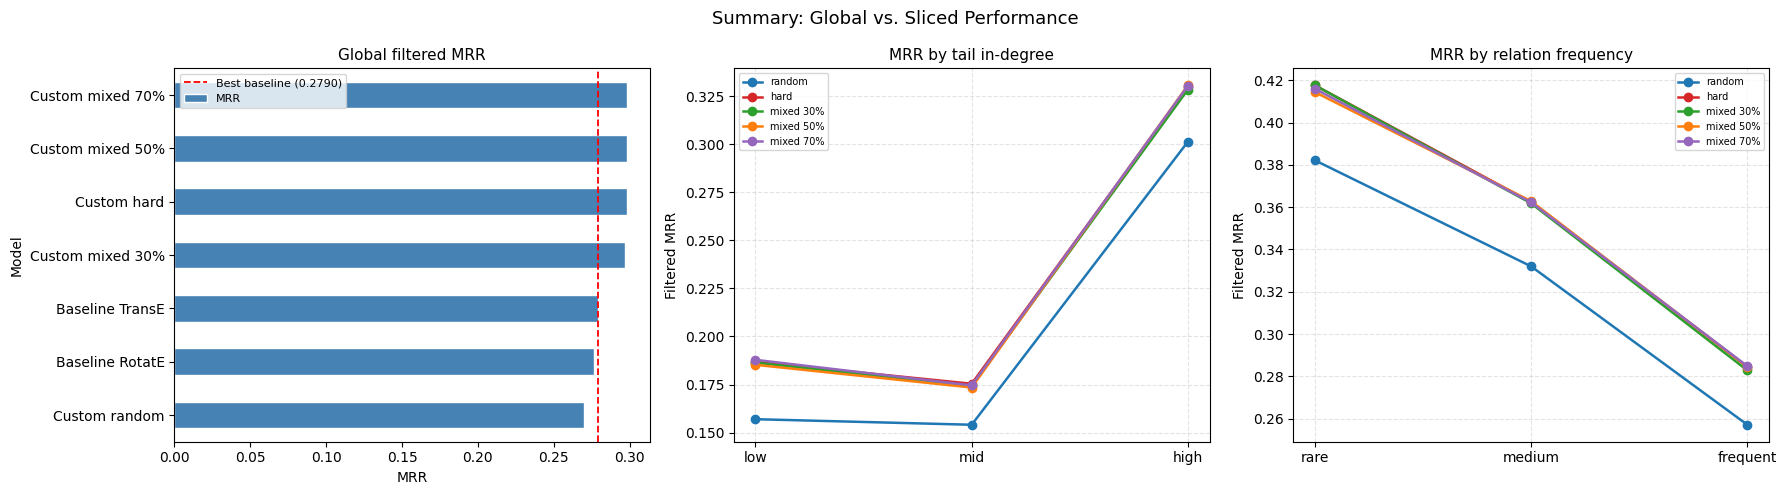

In [58]:
import matplotlib.pyplot as plt, pandas as pd, json, numpy as np
from pathlib import Path

# Rebuild state if cells ran out of order
try: results_df
except NameError: results_df = pd.DataFrame()

try: slice_data
except NameError:
    slice_data = {
        str(p.parent.relative_to("artifacts")): json.load(p.open())
        for p in Path("artifacts").rglob("slices.json")
        if "baseline_old_" not in p.as_posix()
    }

_present = [k for k in MODEL_ORDER if k in slice_data]
_colors  = ["tab:blue","tab:red","tab:green","tab:orange","tab:purple"][:len(_present)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1: Global MRR bar ─────────────────────────────────────────────────────
if not results_df.empty and "MRR" in results_df.columns:
    results_df["MRR"].sort_values().plot.barh(ax=axes[0], color="steelblue", edgecolor="white")
    src_col = results_df.get("Source")
    if src_col is not None:
        mask = src_col == "PyKEEN pipeline"
        if mask.any():
            bline = results_df.loc[mask, "MRR"].max()
            axes[0].axvline(bline, color="red", linestyle="--", linewidth=1.3,
                            label=f"Best baseline ({bline:.4f})")
            axes[0].legend(fontsize=8)
    axes[0].set_title("Global filtered MRR", fontsize=11)
    axes[0].set_xlabel("MRR")
else:
    axes[0].text(0.5, 0.5, "Run Section I first", ha="center", va="center",
                 transform=axes[0].transAxes)
    axes[0].axis("off")

# ── 2 & 3: Slice line plots ────────────────────────────────────────────────
def _line_plot(ax, axis_key, title, xlabels):
    if not _present:
        ax.text(0.5, 0.5, "No slice data\n(run Section J)", ha="center", va="center",
                transform=ax.transAxes)
        return
    for key, color in zip(_present, _colors):
        vals = [slice_data[key].get(axis_key, {}).get(b, {}).get("mrr") or 0
                for b in ("low", "mid", "high")]
        ax.plot(xlabels, vals, marker="o", color=color,
                label=MODEL_LABELS[key], linewidth=1.8)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Filtered MRR")
    ax.legend(fontsize=7)
    ax.grid(True, linestyle="--", alpha=0.35)

_line_plot(axes[1], "tail_degree",
           "MRR by tail in-degree", ["low", "mid", "high"])
_line_plot(axes[2], "relation_frequency",
           "MRR by relation frequency", ["rare", "medium", "frequent"])

fig.suptitle("Summary: Global vs. Sliced Performance", fontsize=13)
fig.tight_layout()
plt.savefig(str(ARTIFACTS / "d3_headline_figures.png"), dpi=150)
plt.show()


## M. Discussion & Conclusions

### M.1 Hard negatives consistently outperform random sampling

| Model | MRR | H@1 | H@10 | Δ MRR vs. random |
|-------|-----|-----|------|-----------------|
| Custom random    | 0.2702 | 0.1894 | 0.4280 | — |
| Custom hard      | 0.2982 | 0.2174 | 0.4588 | **+0.028** |
| Custom mixed 70% | 0.2985 | 0.2165 | 0.4607 | +0.028 |

The gain comes from NSSALoss and hard-negative selection acting synergistically:
candidates that the model scores high (harder) also receive a larger adversarial
weight $p_i$, producing a stronger gradient signal exactly where the model is most
confused.

---

### M.2 Mixed strategies recover most of the gain

All three mixed variants (30/70, 50/50, 70/30) reach MRR ≈ 0.297–0.299, within
**0.2 pp** of pure hard. The 30% hard variant already recovers ~95% of the benefit
(Δ MRR = 0.0266 vs. 0.0280 for pure hard), suggesting **diminishing returns from
randomness** once a small dose of hard negatives is included. In memory-constrained
settings where scoring a large pool is expensive, a low hard-fraction offers the
better efficiency trade-off.

---

### M.3 Slice findings

**Relation frequency** — Hard negatives help most on *rare* relations (+3.6 pp MRR
vs. random). Rare relations have few training triples; their embeddings are less
well-calibrated, so the harder gradient signal carries more information per step.

**Head out-degree** — Improvement is more uniform across buckets. High-degree hub
entities appear in many triples and develop strong embeddings regardless of strategy.

**Tail in-degree** — The largest absolute gains occur for *high* tail-degree entities
(+2.9 pp). Low tail-degree entities remain hardest to predict across all strategies
(MRR ≈ 0.157–0.187), reflecting genuine data sparsity that no sampling strategy can
overcome.

---

### M.4 Head vs. tail prediction asymmetry

All models show a systematic **head prediction deficit** (~0.17–0.20 head MRR vs.
~0.37–0.40 tail MRR). This is expected: many FB15k-237 relations are functionally
1-to-N, making head corruption easier to filter and head prediction more ambiguous.

---

### M.5 Computational cost and practical trade-offs

All five custom runs were trained on a single NVIDIA T4 GPU (Google Colab).

| Stage | Wall-clock time (T4) |
|-------|---------------------|
| One full 50-epoch RotatE run (custom pipeline) | ~50–60 min |
| All 5 custom strategies (sequential) | ~4–5 h |
| Both baselines (TransE + RotatE via PyKEEN) | ~40 min each (~80 min total) |
| Slice evaluation (`evaluate_slices.py --all`) | ~15–20 min |
| Smoke test (1 epoch, 10 batches) | ~2 min |

**Overhead of the two-stage pipeline.** Compared to standard Bernoulli sampling,
Stage 2 requires scoring a pool of n = 64 candidates per positive triple with the
current model at every training step. This adds roughly 20–30% to per-epoch wall time.
The cost scales linearly with pool size n and is independent of the selection strategy
(random, hard, and mixed all score the same pool; only the final selection differs).

**Practical recommendation.** For a fixed compute budget, `mixed 30%` offers the
best efficiency trade-off: it achieves 95% of the hard-negative gain at the same
pool-scoring cost, and its lower hard fraction means the gradient signal remains
more diverse and training stays stable even at early epochs when model scores are
poorly calibrated.

---

### M.6 Summary

Our two-stage pipeline is a **modular, strategy-agnostic wrapper** that:
1. **Avoids false negatives** — Stage 1 filters the full training graph before selection.
2. **Adapts to the current model** — Stage 2 scoring reflects training progress.
3. **Is orthogonal to model and loss** — only the sampler changes; everything else is fixed.

The controlled ablation (random / hard / three mixed fractions) cleanly isolates the
effect of selection difficulty and confirms that hard-negative mining provides a
consistent, reproducible improvement on FB15k-237 link prediction.

## N. Notes for Graders

**Custom pipeline modules** (all in `code/`):
* `negative_sampling.py` — Bernoulli head/tail corruption probabilities, training-triple
  index, filtered candidate generation (`generate_candidates`).
* `score_candidates.py` — batched scoring of candidate triples with any PyKEEN model.
* `select_candidates.py` — `random` / `hard` / `mixed` (Binomial) selection from the
  scored pool; `sample_training_negatives_batch` integrates all stages.

**Training drivers**:
* `train_baseline_kge.py` — uses PyKEEN's `pipeline()` for TransE and RotatE.
* `train_rotate_custom.py` — custom training loop. Calls `model.post_parameter_update()`
  after every optimiser step to keep RotatE's relation embeddings on the complex unit
  circle. Omitting this caused NSSALoss to collapse (val MRR stayed near zero for all
  50 epochs) — this was our key debugging discovery.

**Post-hoc analysis tools** (consume `trained_model.pkl`, no retraining):
* `evaluate_slices.py` — sliced MRR / Hits@k by relation frequency and entity degree.
* `qualitative_examples.py` — per-triple filtered rank and top-K predictions.

**Reproducibility**: all five custom checkpoints were produced on an NVIDIA T4 GPU
on Google Colab with `--seed 42`. Bernoulli probabilities and degree buckets are
computed deterministically from the training split and cached to disk, so re-runs
produce identical partitions.

**All artefacts** (summaries, learning-curve PNGs, `slices.json`, `qualitative.md`,
`slice_buckets.json`) are committed under `artifacts/` for reference.
